# 실습 내용

- 데이터 : diabetes.csv
- 개별 알고리즘으로 모델을 만들어 성능을 확인한다.
- Stacking 앙상블을 사용해 모델을 만들어 성능을 확인한다.

# 1.환경 준비

In [56]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [57]:
path = 'data/diabetes.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [58]:
# 상위 몇 개 행 확인
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [59]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**데이터설명**

피마 인디언 당뇨 데이터셋은 몇 명의 여성 피마 인디언의 진료 자료와 진단 후 5년 내 당뇨 발병 여부로 구성됨

- Pregnancies: 임신 횟수
- Glucose: 포도당 부하 검사 수치
- BloodPressure: 혈압(mm Hg)
- SkinThickness: 팔 삼두근 뒤쪽의 피하지방 측정값(mm)
- Insulin: 혈청 인슐린(mu U/ml)
- BMI: 체질량지수(체중(kg)/키(m))^2
- DiabetesPedigreeFunction: 당뇨 내력 가중치 값
- Age: 나이
- Outcome: 클래스 결정 값(0 또는 1)

**diabetes**

- 당뇨병(糖尿病, diabetes)은 높은 혈당 수치가 오랜 기간 지속되는 대사 질환이다.
- 혈당이 높을 때의 증상으로는 소변이 잦아지고, 갈증과 배고픔이 심해진다.
- 이를 치료하지 않으면 다른 합병증을 유발할 수 있다.
(출처: 위키백과)

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# 3.데이터 전처리

**1) x, y 분리**

In [61]:
target = 'Outcome'

X = df.drop(target, axis=1)
y = df[target]

**2) 학습용, 평가용 데이터 분리**

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=1
                                                    )

**3) 정규화**

In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# 4.모델링

## 4.1.Decision Tree 모델링

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 성능 정보 수집
result = {}
result['Decision Tree'] = accuracy_score(y_test, y_pred)

[[118  28]
 [ 41  44]]
              precision    recall  f1-score   support

           0       0.74      0.81      0.77       146
           1       0.61      0.52      0.56        85

    accuracy                           0.70       231
   macro avg       0.68      0.66      0.67       231
weighted avg       0.69      0.70      0.70       231



## 4.2.KNN 모델링

In [65]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(X_train_s, y_train)

y_pred = model_knn.predict(X_test_s)

# 평가하기
print("CM :",confusion_matrix(y_test, y_pred))
print("CR :",classification_report(y_test, y_pred))

# 성능정보 수집
result['KNN'] = accuracy_score(y_test, y_pred)

CM : [[129  17]
 [ 35  50]]
CR :               precision    recall  f1-score   support

           0       0.79      0.88      0.83       146
           1       0.75      0.59      0.66        85

    accuracy                           0.77       231
   macro avg       0.77      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231



## 4.3.Logistic Regression 모델링

In [66]:
from sklearn.linear_model import LogisticRegression

model_lrg= LogisticRegression(max_iter=1000)

model_lrg.fit(X_train, y_train)

y_pred = model_lrg.predict(X_test)

# 평가하기
print("MAE:",confusion_matrix(y_test, y_pred))
print("R2: ",classification_report(y_test, y_pred))

# 성능정보 수집
result['Logistic Regression'] = accuracy_score(y_test, y_pred)

MAE: [[132  14]
 [ 36  49]]
R2:                precision    recall  f1-score   support

           0       0.79      0.90      0.84       146
           1       0.78      0.58      0.66        85

    accuracy                           0.78       231
   macro avg       0.78      0.74      0.75       231
weighted avg       0.78      0.78      0.78       231



## 4.4.LightGBM 모델링

In [67]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(min_child_samples=5,     # 리프 노드 하나에 5개 데이터만 있어도 허용, 하나의 리프 노드에 최소 몇 개의 데이터가 있어야 하는지.
                           max_depth=15,            # 트리의 최대 깊이
                           min_split_gain=0.0,      # 노드를 한 번 더 나눌 때 최소한 어느 정도 정보 이득이 있어야 하는지. 0.0 : 거의 제한을 두지 않는 설정.
                           colsample_bytree=1.0,    # 각 트리를 만들 때 전체 컬럼 중 몇 %를 사용할 것인지. 0.8 : 컬럼이 10개라면 매 트리마다 8개 컬럼 정도만 랜덤 사용.
                           verbose=-1               
                           )

model_lgbm.fit(X_train, y_train)

y_pred = model_lgbm.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

result['LightGBM'] = accuracy_score(y_test, y_pred)

[[130  16]
 [ 31  54]]
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       146
           1       0.77      0.64      0.70        85

    accuracy                           0.80       231
   macro avg       0.79      0.76      0.77       231
weighted avg       0.79      0.80      0.79       231



## 4.5.Stacking 모델링

In [68]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier

# 모델 설정하기(사용할 모델들을 지정)
estimators = [('lr', make_pipeline(MinMaxScaler(), LogisticRegression())),
              ('knn', make_pipeline(MinMaxScaler(), KNeighborsRegressor())),
              ('dt', DecisionTreeClassifier()),
              ('lgb', LGBMClassifier())]

model = StackingClassifier(estimators=estimators,
                           final_estimator=RandomForestClassifier())

# 학습하기
model.fit(X_train, y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 성능정보 수집
result['Stacking'] = accuracy_score(y_test, y_pred)

[[122  24]
 [ 36  49]]
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       146
           1       0.67      0.58      0.62        85

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



# 5.성능 비교

- 위에서 수집한 성능 정보를 시각화해 비교한다.

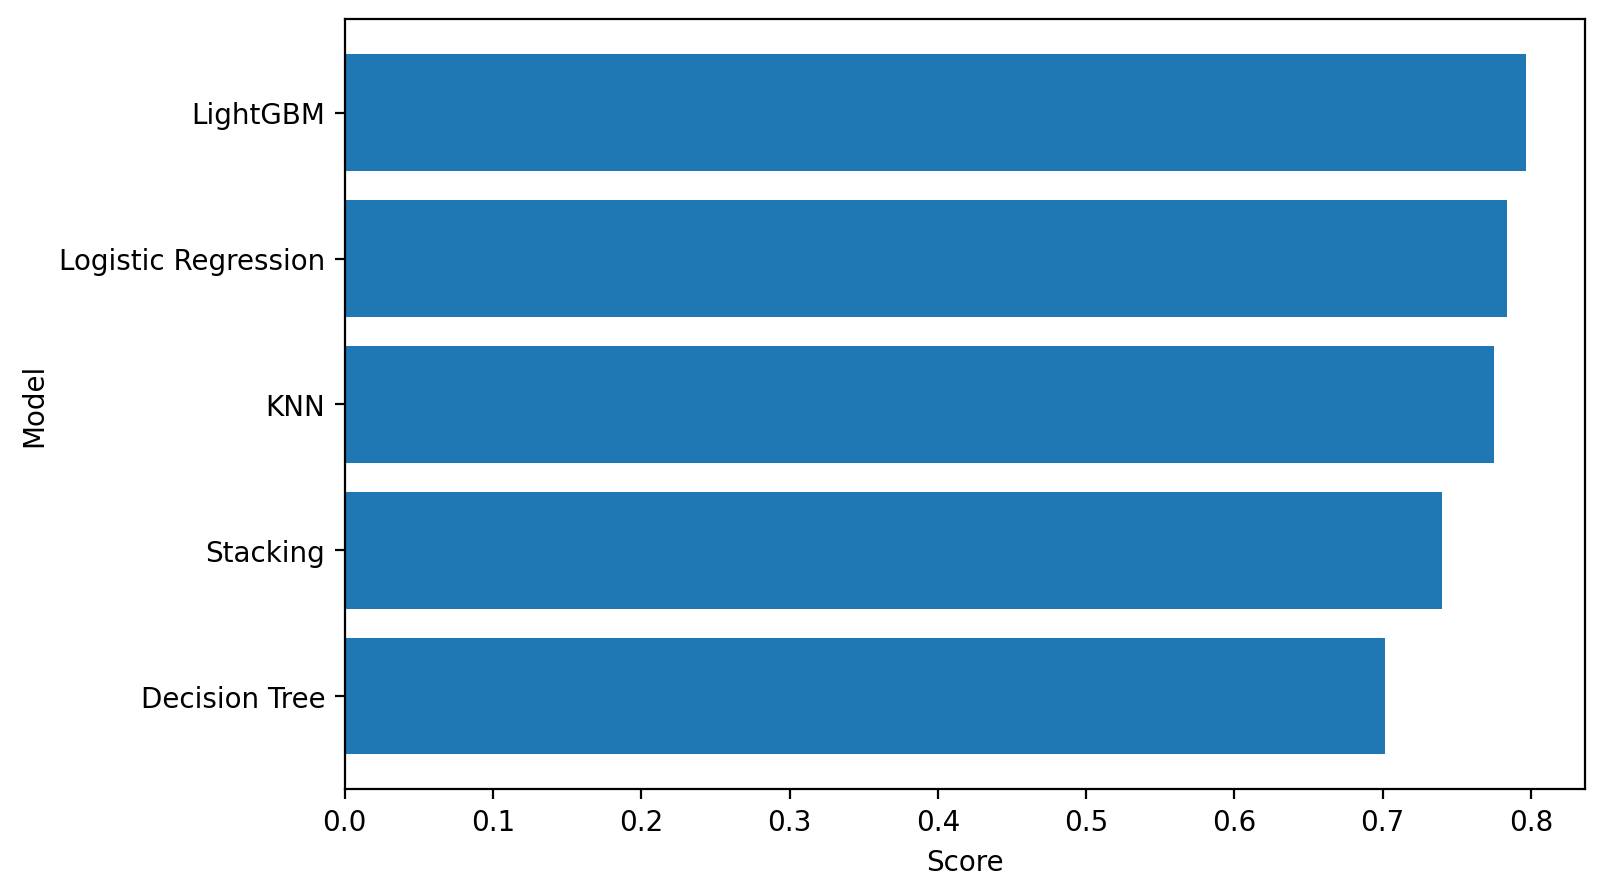

In [69]:
# 데이터 프레임 만들기
df_result = pd.DataFrame.from_dict(result, orient='index', columns=['score'])
df_result.sort_values(by='score', ascending=True, inplace=True)

plt.figure(figsize=(8,5))
plt.barh(y=df_result.index, width=df_result['score'])
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()